In [ ]:
from sklearn.datasets._samples_generator import make_regression
X,y=make_regression(n_samples=200,n_features=1,n_informative=1,noise=5,bias=40,random_state=200)
m=200 #number of sample
#- noise=5 → Adds Gaussian noise with standard deviation 5 to make the data more realistic (not perfectly linear).
#bias ->-  Adds a constant offset of 40 to the target values y.
# - random_state=200 → Fixes the random seed so the dataset is reproducible (you’ll get the same numbers every run).
#- Outputs:
# - X → The input features (shape: 300\times 1).
# - y → The target values (shape: 300).


In [44]:
import numpy as np
X = (X - np.mean(X)) / np.std(X)

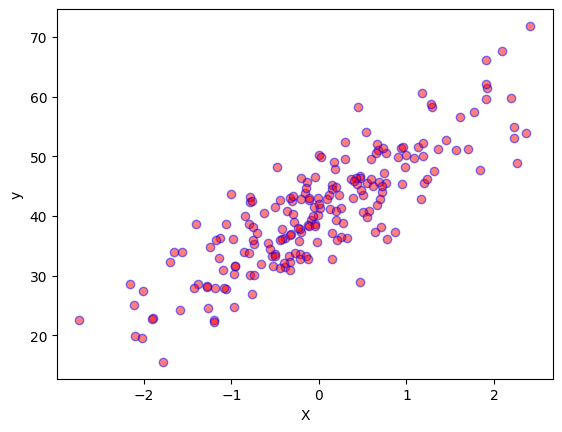

In [45]:
from matplotlib import pyplot as plt
plt.scatter(X,y,c='red',marker='o',alpha=0.5,edgecolors='blue')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [46]:
##linear model
import numpy as np

def h(X,w):
    return (w[1]*np.array(X[:,0])+w[0])


In [47]:
#cost function
def cost(w,X,y):
    return (np.sum(np.square(h(X,w)-np.array(y))))*(.5/m)

In [48]:
#gradient descent
def grad(w,X,y):  #partial derivative
    g=[0]*2
    g[0]=(1/m)*np.sum(h(X,w)-np.array(y))
    g[1]=(1/m)*np.sum((h(X,w)-np.array(y))*np.array(X[:,0]))
    # scalar*vactor->vector that lead to w1 to be array not number so we have to fix it by element  wise multiplication 
    # g[1]=(1/m)*np.sum(m*X[:,0])
    return g

In [49]:
def descent(w_new,w_prev,lr):
    print(w_prev)
    print(cost(w_prev,X,y))
    j=0
    while True:
        w_prev=w_new
        w0 = w_prev[0] - lr * grad(w_prev, X, y)[0]
        w1 = w_prev[1] - lr * grad(w_prev, X, y)[1]
        w_new=[w0,w1]
        print(w_new)
        print(cost(w_new,X,y))
        if(w_new[0]-w_prev[0])**2+(w_new[1]-w_prev[1])**2<=1e-6:
            return w_new
        if j>500:
            return w_new

        j+=1

In [50]:
w=[0,-1]
# x=[0,-1]

In [53]:
w=descent(w,w,.1)
print(w)

[np.float64(40.570696994780704), np.float64(8.091855472413096)]
13.223170267584488
[np.float64(40.596992767669384), np.float64(8.097748330666679)]
13.216271429807492
[np.float64(40.6206589632692), np.float64(8.103051903094903)]
13.210683371208125
[np.float64(40.64195853930903), np.float64(8.107825118280305)]
13.206157043742639
[np.float64(40.661128157744876), np.float64(8.112121011947167)]
13.202490718495596
[np.float64(40.67838081433714), np.float64(8.115987316247342)]
13.19952099504549
[np.float64(40.693908205270176), np.float64(8.1194669901175)]
13.197115519050904
[np.float64(40.70788285710991), np.float64(8.122598696600642)]
13.195167083495294
[np.float64(40.72046004376567), np.float64(8.12541723243547)]
13.193588850695242
[np.float64(40.73177951175585), np.float64(8.127953914686815)]
13.192310482127205
[np.float64(40.74196703294702), np.float64(8.130236928713027)]
13.191275003587096
[np.float64(40.751135802019064), np.float64(8.132291641336616)]
13.190436265969607
[np.float64(40.7

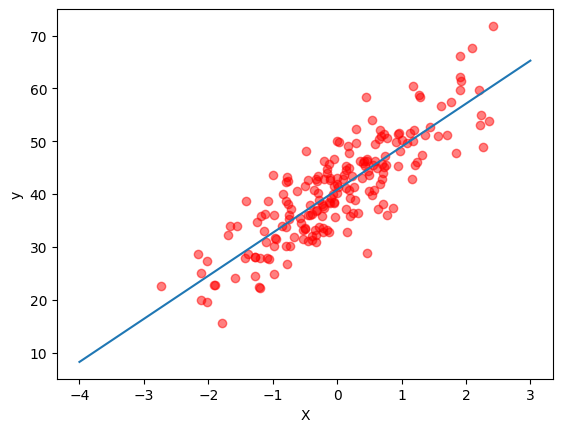

In [54]:
def graph(formula,x_range):
    x=np.array(x_range)
    y=formula(x)
    plt.plot(x,y)

def my_formula(x):
    return w[0]+w[1]*x

plt.scatter(X,y,c='red',alpha=.5,marker='o')
graph(my_formula,range(-4,4))
plt.xlabel('X')
plt.ylabel('y')
plt.show()